# Oxford Pets — Segmentation Evaluation

DINOv2 ViT-S/14 (frozen) + UPerNetHead  
3 classes: **0=background**, **1=pet**, **2=boundary**

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

REPO      = Path("..").resolve()
DATA_DIR  = REPO / "experiments" / "datasets" / "oxford_pets_seg"
CKPT_PATH = REPO / "experiments" / "results" / "seg_pets" / "checkpoints" / "best-epoch=4-val_loss=0.1770.ckpt"
INPUT_SIZE  = 224
NUM_CLASSES = 3
CLASS_NAMES = ["background", "pet", "boundary"]
COLORS      = np.array([[50, 50, 50], [255, 100, 50], [100, 200, 255]], dtype=np.uint8)  # bg, pet, boundary

print("PyTorch:", torch.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu.name}  {gpu.total_memory/1e9:.1f} GB")
else:
    print("GPU: not available — using CPU")
print("Device:", device)

PyTorch: 2.5.1+cu121
GPU: NVIDIA GeForce RTX 2060  6.4 GB
Device: cuda


C:\Users\dhruv\.conda\envs\fft\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1  Load model from checkpoint

In [2]:
from core.encoders import create_encoder
from core.decoders.segmentation import UPerNetHead
from core.training.trainer import DecoderLightningModule

encoder = create_encoder("dinov2_vits14", input_size=INPUT_SIZE)
decoder = UPerNetHead(encoder, num_classes=NUM_CLASSES, fpn_channels=256, output_size=INPUT_SIZE)

lightning_module = DecoderLightningModule.load_from_checkpoint(
    CKPT_PATH,
    decoder=decoder,
)
decoder = lightning_module.decoder.to(device).eval()
encoder = encoder.to(device)
print(f"Loaded checkpoint: {CKPT_PATH.name}")
print(f"Trainable params: {decoder.num_trainable_params():,}")

Using cache found in C:\Users\dhruv/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\dhruv/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\dhruv/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\dhruv/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


C:\Users\dhruv\.conda\envs\fft\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loaded checkpoint: best-epoch=4-val_loss=0.1770.ckpt
Trainable params: 6,410,243


## 2  Build validation dataset

In [3]:
from core.data.dataset import FFTDataset

dataset  = FFTDataset.from_folder(DATA_DIR, task="segmentation",
                                   transform=encoder.get_transform(), output_size=INPUT_SIZE)
_, val_ds = dataset.split(seed=42)
print(f"Val samples: {len(val_ds)}")

Val samples: 736


## 3  Full-val mIoU sweep

In [4]:
from torchmetrics.classification import MulticlassJaccardIndex

miou_metric     = MulticlassJaccardIndex(num_classes=NUM_CLASSES, average="macro").to(device)
per_class_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES, average="none").to(device)

with torch.no_grad():
    for idx in tqdm(range(len(val_ds)), desc="Evaluating"):
        sample = val_ds[idx]
        image_t = sample["image"].unsqueeze(0).to(device)
        mask_t  = sample["mask"].unsqueeze(0).to(device)   # (1, H, W)

        features = encoder.forward_features(image_t)
        logits   = decoder(features)                        # (1, C, H, W)
        pred     = logits.argmax(dim=1)                     # (1, H, W)

        miou_metric.update(pred, mask_t)
        per_class_metric.update(pred, mask_t)

miou        = miou_metric.compute().item()
per_class   = per_class_metric.compute().cpu().numpy()

print(f"\nmIoU (macro):   {miou*100:.2f}%")
print("Per-class IoU:")
for name, iou in zip(CLASS_NAMES, per_class):
    print(f"  {name:12s}: {iou*100:.2f}%")

Evaluating:   0%|          | 0/736 [00:00<?, ?it/s]

Evaluating:   0%|          | 1/736 [00:00<04:48,  2.55it/s]

Evaluating:   1%|          | 5/736 [00:00<00:58, 12.53it/s]

Evaluating:   1%|          | 9/736 [00:00<00:37, 19.51it/s]

Evaluating:   2%|▏         | 13/736 [00:00<00:29, 24.49it/s]

...

Evaluating:  99%|█████████▉| 727/736 [00:20<00:00, 35.51it/s]

Evaluating:  99%|█████████▉| 731/736 [00:20<00:00, 35.56it/s]

Evaluating: 100%|█████████▉| 735/736 [00:20<00:00, 36.13it/s]

Evaluating: 100%|██████████| 736/736 [00:20<00:00, 35.31it/s]


mIoU (macro):   78.82%
Per-class IoU:
  background  : 94.05%
  pet         : 88.18%
  boundary    : 54.24%


## 4  Visualise predictions vs ground-truth

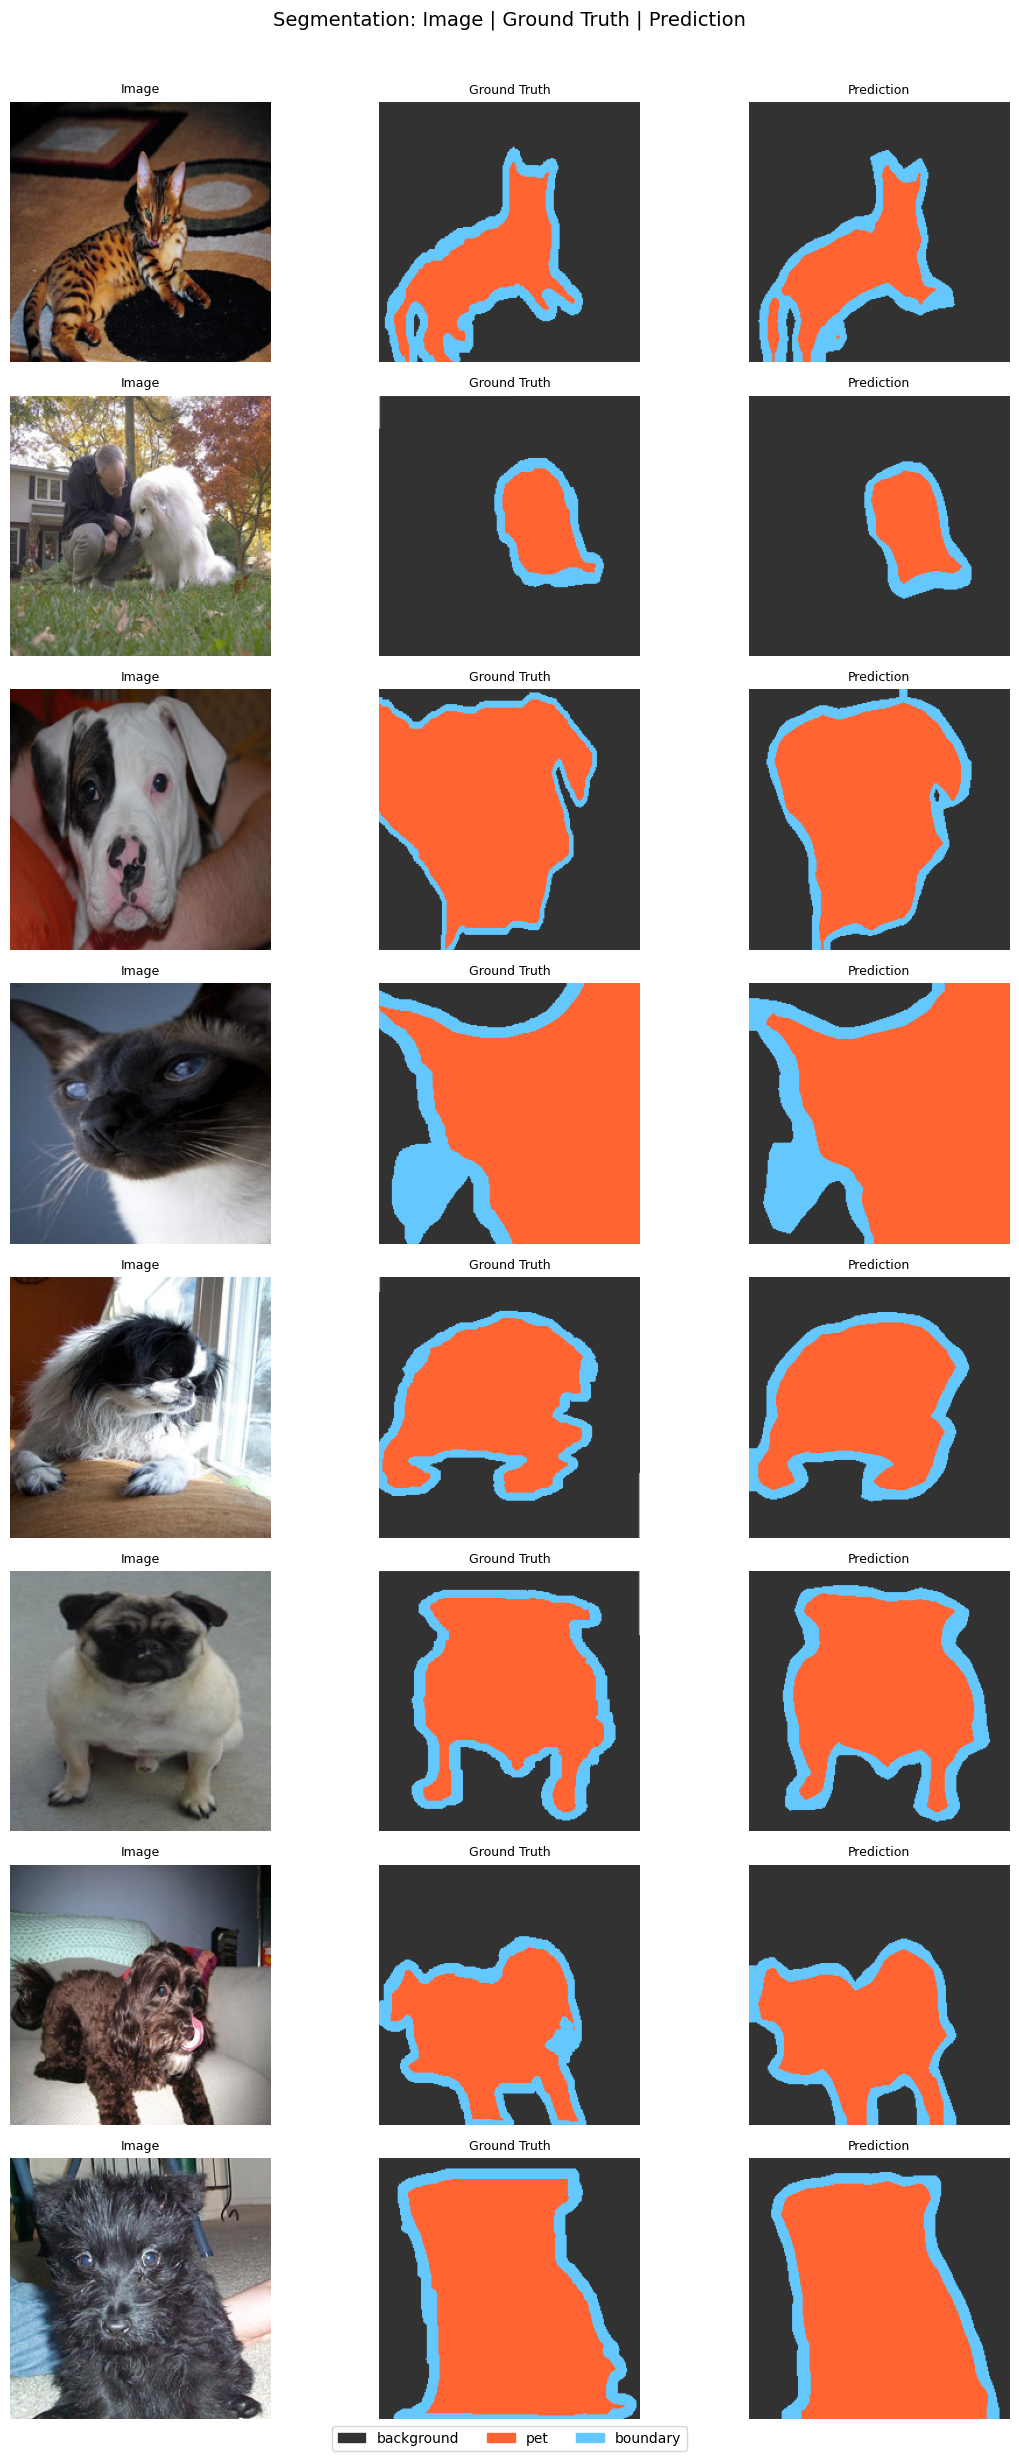

In [5]:
def colorize(mask_np: np.ndarray) -> np.ndarray:
    """Map integer class mask → RGB using COLORS palette."""
    return COLORS[mask_np.clip(0, NUM_CLASSES - 1)]


rng     = np.random.RandomState(7)
indices = rng.choice(len(val_ds), size=8, replace=False)

fig, axes = plt.subplots(len(indices), 3, figsize=(12, len(indices) * 3))
fig.suptitle("Segmentation: Image | Ground Truth | Prediction", fontsize=14, y=1.01)

with torch.no_grad():
    for row, idx in enumerate(indices):
        sample  = val_ds[idx]
        image_t = sample["image"].unsqueeze(0).to(device)
        gt_mask = sample["mask"].numpy()                   # (H, W)

        features = encoder.forward_features(image_t)
        logits   = decoder(features)
        pred_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()  # (H, W)

        # Un-normalise image for display
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img_np = sample["image"].permute(1, 2, 0).numpy()
        img_np = (img_np * std + mean).clip(0, 1)

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title("Image", fontsize=9)
        axes[row, 1].imshow(colorize(gt_mask))
        axes[row, 1].set_title("Ground Truth", fontsize=9)
        axes[row, 2].imshow(colorize(pred_mask))
        axes[row, 2].set_title("Prediction", fontsize=9)
        for ax in axes[row]:
            ax.axis("off")

legend_patches = [mpatches.Patch(color=COLORS[i]/255, label=CLASS_NAMES[i]) for i in range(NUM_CLASSES)]
fig.legend(handles=legend_patches, loc="lower center", ncol=NUM_CLASSES, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout()
plt.show()

## 5  Per-class IoU bar chart

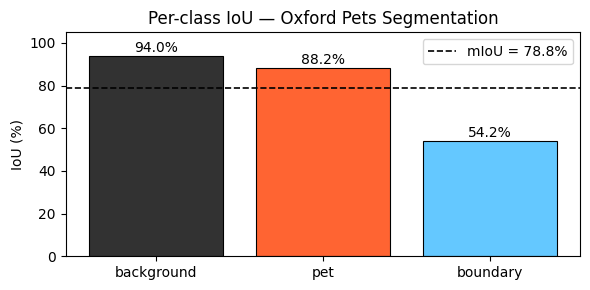

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(CLASS_NAMES, per_class * 100,
              color=[c/255 for c in COLORS], edgecolor="black", linewidth=0.8)
ax.axhline(miou * 100, color="black", linestyle="--", linewidth=1.2, label=f"mIoU = {miou*100:.1f}%")
for bar, iou in zip(bars, per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{iou*100:.1f}%", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("IoU (%)")
ax.set_ylim(0, 105)
ax.set_title("Per-class IoU — Oxford Pets Segmentation")
ax.legend()
plt.tight_layout()
plt.show()